# Task 1: Burnout Prediction

In this notebook I look at several factors associated with employee burnout and try to predict whether an employee will/is experiencing burnout.

In [2]:
import sys

sys.path.append("/Users/jared.mcbride/Documents/Code Projects/SVU-AI/Unit 2: Neural Networks Basics/")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import Neurons

In [3]:
df = pd.read_csv("/Users/jared.mcbride/Documents/Code Projects/SVU-AI/Unit 2: Neural Networks Basics/synthetic_employee_burnout.csv")

df.tail()

,Name,Age,Gender,JobRole,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout
1995,Leo Brown,41,Female,Manager,4,63,17,3.40,4,0
1996,Alex Brown,23,Female,HR,2,39,20,4.67,9,0
1997,Nina Wang,31,Female,HR,10,39,4,4.10,4,0
1998,Kate Lee,25,Male,HR,0,40,57,2.11,4,0
1999,Lily Petrov,49,Female,Engineer,13,65,22,4.36,8,0


In [4]:
df = pd.read_csv("/Users/jared.mcbride/Documents/Code Projects/SVU-AI/Unit 2: Neural Networks Basics/synthetic_employee_burnout.csv")

del df["Name"]

df = pd.get_dummies(df, columns=["Gender", "JobRole"])

df.tail()

,Age,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout,Gender_Female,Gender_Male,JobRole_Analyst,JobRole_Engineer,JobRole_HR,JobRole_Manager,JobRole_Sales
1995,41,4,63,17,3.40,4,0,True,False,False,False,False,True,False
1996,23,2,39,20,4.67,9,0,True,False,False,False,True,False,False
1997,31,10,39,4,4.10,4,0,True,False,False,False,True,False,False
1998,25,0,40,57,2.11,4,0,False,True,False,False,True,False,False
1999,49,13,65,22,4.36,8,0,True,False,False,True,False,False,False


In [5]:
df = df.sample(frac = 1).reset_index(drop=True)

df.tail()

Y = df.pop("Burnout")
Y = Y.to_numpy()
Y = np.where(Y == 0, -1, 1)

X = df.to_numpy()
X

array([[36, 15, 49, ..., True, False, False],
       [53, 31, 67, ..., False, False, False],
       [35, 1, 64, ..., False, False, False],
       ...,
       [57, 0, 57, ..., False, False, False],
       [26, 0, 42, ..., False, True, False],
       [45, 24, 36, ..., False, False, True]], dtype=object)

In [6]:
np.unique(Y)

array([-1,  1])

In [7]:
X_train = X[:1400,:]
X_test  = X[1400:,:]

Y_train = Y[:1400]
Y_test  = Y[1400:]

Y_test.shape

(600,)

In [8]:
ada = Neurons.Adaline(eta = 0.000_000_1, n_epochs = 100)
ada.fit(X_train, Y_train)

ada.cost_

[412.08618252089076,
 220.15958993379152,
 215.46966673900624,
 211.48289081837666,
 208.08805589474798,
 205.1933645920303,
 202.72136665179144,
 200.6067123256205,
 198.79425776489327,
 197.23746722732923,
 195.89706559238917,
 194.73990196514458,
 193.7379912939628,
 192.8677061099653,
 192.10909486678582,
 191.44530704482509,
 190.86210829235526,
 190.34747149692603,
 189.89123189092405,
 189.48479615915326,
 189.1208970882419,
 188.79338662331435,
 188.4970613152559,
 188.22751508463134,
 187.98101502333148,
 187.75439662545298,
 187.5449754043046,
 187.35047232920596,
 187.16895091784738,
 186.99876415904797,
 186.83850972667202,
 186.68699218666106,
 186.5431911024228,
 186.4062341153872,
 186.27537422209434,
 186.14997059119477,
 186.02947236656308,
 185.9134049894739,
 185.8013586459468,
 185.69297850703427,
 185.5879564818654,
 185.48602424712828,
 185.38694735366226,
 185.2905202420484,
 185.1965620253926,
 185.1049129196908,
 185.0154312208784,
 184.92799074345726,
 184.842

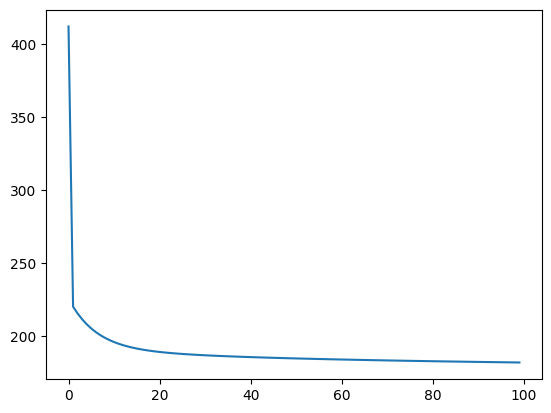

In [9]:
plt.plot(ada.cost_)

In [10]:
error_rate = np.mean(Y_test != ada.predict(X_test))
error_rate

0.065

In [11]:
burnout_rate = sum(Y_test == 1)/sum(Y_test == -1)

burnout_rate

0.06951871657754011

## Standardize

In [12]:
mu  = X_train.mean(axis=0)
# For some reason, np.std(X_train, axis=0) gives an error here
sig = np.array([np.std(X_train[:,i]) for i in range(X_train.shape[1])])

X_train_std = (X_train - mu) / sig
X_test_std  = (X_test  - mu) / sig

In [13]:
adas = Neurons.Adaline(eta = 0.0001, n_epochs = 100)
adas.fit(X_train_std, Y_train)
adas.cost_

[715.5948987884218,
 564.0638335385717,
 451.9912259411093,
 369.09233061720096,
 307.7669383446721,
 262.39702535268407,
 228.82888383084602,
 203.99094380474153,
 185.6115557038526,
 172.01049356386864,
 161.94487021980044,
 154.49523615732846,
 148.98136669791538,
 144.89999016248342,
 141.87873512258042,
 139.64206914898836,
 137.98610463276265,
 136.7599620569886,
 135.85198312942552,
 135.17953112606753,
 134.68144470086222,
 134.31245458570174,
 134.03905240876563,
 133.83643382338795,
 133.6862364742351,
 133.57486605694726,
 133.49225752229353,
 133.43095826803582,
 133.38544959751323,
 133.3516444998912,
 133.32651591706443,
 133.30782158111663,
 133.29390032473808,
 133.28352129185677,
 133.27577230370957,
 133.26997720810996,
 133.26563468332515,
 133.26237292433368,
 133.2599160870601,
 133.2580594376687,
 133.25665094705056,
 133.25557765757543,
 133.25475558363385,
 133.25412222908056,
 133.25363104272392,
 133.25324730923396,
 133.25294510327925,
 133.252705031301,
 133

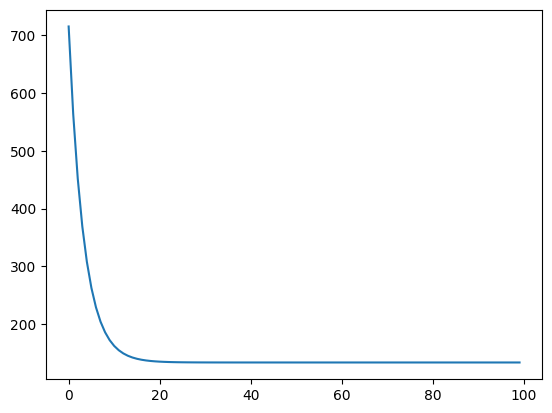

In [14]:
plt.plot(adas.cost_)

In [15]:
error_rate_std = np.mean(Y_test != adas.predict(X_test_std))
error_rate_std

0.065

In [16]:
Y = np.where(Y == -1, 0, 1)
np.unique(Y)

np.bincount(Y)/len(Y)

array([0.9355, 0.0645])

# PCA

In [17]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X)
X_reduced.shape

(2000, 3)

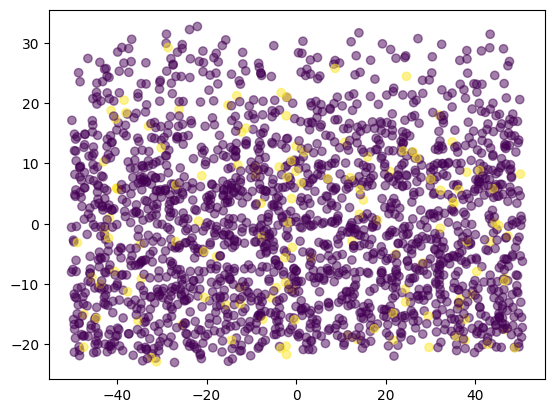

In [18]:
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=Y, cmap='viridis', alpha=0.5)

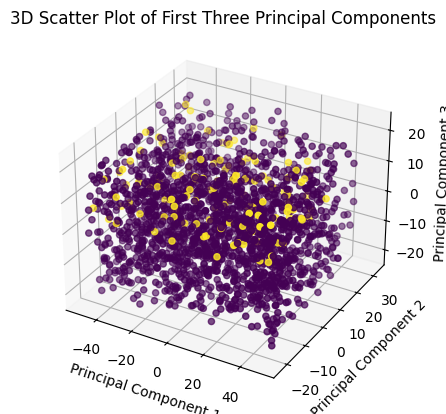

In [19]:
# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the first three principal components
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=Y, marker='o')

# Set axis labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Show the plot
plt.title("3D Scatter Plot of First Three Principal Components")
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
Y_train_m = np.where(Y_train == -1, 0, 1)
Y_test_m  = np.where(Y_test  == -1, 0, 1)

model=LogisticRegression(class_weight="balanced")
model.fit(X_train_std,Y_train_m)

LogisticRegression(class_weight='balanced')

In [22]:
error_rate_lr = np.mean(Y_test_m != model.predict(X_test_std))
error_rate_lr

0.065

In [23]:
burnout_rate = sum(Y_test == 1)/sum(Y_test == -1)
burnout_rate

0.06951871657754011

In [24]:
X_train_std.mean(axis=0)

array([-7.454354593911765e-18, -1.0142680346396966e-16,
       3.612189912262563e-17, 9.706521301008512e-17,
       2.1545860333966565e-15, -6.042785319745495e-17,
       -9.563778340699563e-17, 9.563778340699563e-17,
       1.8770699280626753e-16, 1.019581244828974e-15,
       2.9658815086414894e-17, -3.9603241321271656e-16,
       1.5860328923216522e-16], dtype=object)